In [1]:
import numpy as np
import pyroomacoustics as pra
import matplotlib.pyplot as plt
from scipy.linalg import eig

from numpy.fft import irfft
import soundfile as sf

import scipy.io.wavfile as wav

In [2]:
# Some variables that can be changed
nbr_bounces = 3
air_absorption = True

fs = 16000   # Sampling freq. of the played audio
room_dim = [5.0, 5.0, 5.0]

num_speakers_per_row = 10

(<Figure size 640x480 with 1 Axes>, <Axes3D: >)

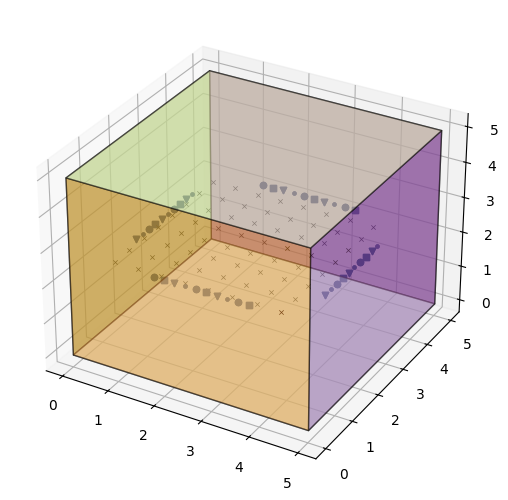

In [4]:
# max_order: max number of reflections in the room
# air_absorbtion: if air is absorbed or not
room = pra.ShoeBox(room_dim, fs=fs, max_order=nbr_bounces, air_absorption=air_absorption)

# Define coordinates for microphones on all 4 walls (Front, Right, Back, Left)
speaker_x = np.linspace(1.5, 3.5, num_speakers_per_row)
speaker_locs_front = np.vstack((speaker_x, np.full(num_speakers_per_row, 0.5), np.full(num_speakers_per_row, 2.5)))
speaker_locs_right = np.vstack((np.full(num_speakers_per_row, 4.5), speaker_x, np.full(num_speakers_per_row, 2.5)))
speaker_locs_back  = np.vstack((speaker_x, np.full(num_speakers_per_row, 4.5), np.full(num_speakers_per_row, 2.5)))
speaker_locs_left  = np.vstack((np.full(num_speakers_per_row, 0.5), speaker_x, np.full(num_speakers_per_row, 2.5)))

# Combine all 4 arrays into one master speaker list
all_speakers = np.hstack((speaker_locs_front, speaker_locs_right, speaker_locs_back, speaker_locs_left))
num_speakers = all_speakers.shape[1]

# Add all speakers to the room
for loc in all_speakers.T:
    room.add_source(loc)

# Microphone Grid
spacing = 0.5
x_coords = np.arange(0.6, 4.4, spacing)
y_coords = np.arange(0.6, 4.4, spacing)
X, Y = np.meshgrid(x_coords, y_coords)
mics_locs = np.vstack((X.flatten(), Y.flatten(), np.full(X.size, 2.5)))
num_mics = mics_locs.shape[1]    # The total number of microphones. Used later
mic_array = pra.MicrophoneArray(mics_locs, room.fs)
room.add_microphone_array(mic_array)

# Plotting
room.plot()

In [6]:
nfft = 512*2      # The number of frequency grid points we want to have

print('Computing RIR...')
room.compute_rir()

# A 3D matrix to save the fft of each RIR
print('Computing H...')
H_full = np.zeros((num_mics, num_speakers, nfft//2 + 1), dtype=complex)    # All zeros in the beginning
for m in range(num_mics):
    for s in range(num_speakers):
        H_full[m, s, :] = np.fft.rfft(room.rir[m][s], n=nfft)
f_axis = np.fft.rfftfreq(nfft, d=1/fs)

Computing RIR...
Computing H...


In [10]:
# These attributes can be changed to create a signal of your choice
audio_freq = np.array([400, 500, 600])
audio_amp = np.array([1, 1, 1])
audio_phase = np.array([np.pi, np.pi/2, 0])
duration = 2.0  # seconds

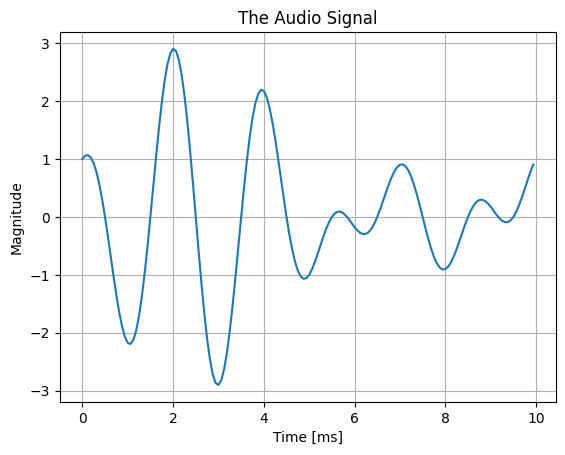

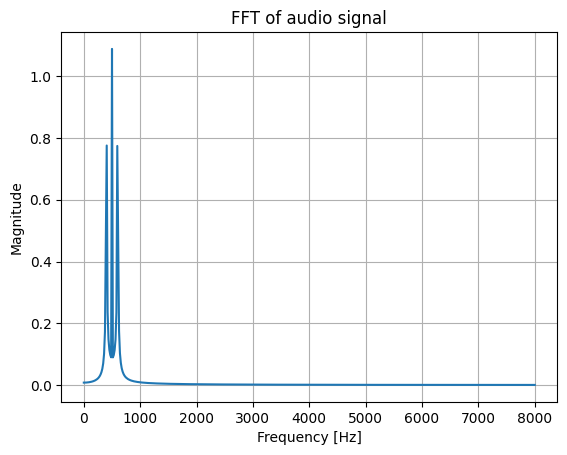

In [14]:
t_axis = np.arange(0, duration, 1/fs)    

audio_time = np.zeros(len(t_axis))

for idx, freq in enumerate(audio_freq):
    if len(audio_amp) == 1:
        # all the parts of the signal have the same frequency
        audio_time += audio_amp * np.sin(2 * np.pi * freq * t_axis  + audio_phase)
    else:
        audio_time += audio_amp[idx] * np.sin(2 * np.pi * freq * t_axis  + audio_phase[idx])

# The frequencies of the signal (division of nfft/2 for the magnitude to be correct)
audio_fft = np.fft.rfft(audio_time, n=nfft) 

plt.plot(t_axis[:int(0.01 * fs)]*1_000, audio_time[:int(0.01 * fs)])
plt.xlabel("Time [ms]")
plt.ylabel("Magnitude")
plt.title("The Audio Signal")
plt.grid(True)
plt.show()

plt.plot(f_axis, np.abs(audio_fft)/(nfft/2))
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.title("FFT of audio signal")
plt.grid(True)
plt.show()

In [15]:
# Some needed contants
c = pra.constants.get('c')          # Speed of sound

energy_tot = 0

# Define the centers and radius for the circular zones
radius = 0.5
bright_center = np.array([1.5, 3.0, 2.5])
dark_center = np.array([3.5, 3.0, 2.5])
dist_to_bright = np.sqrt((mics_locs[0, :] - bright_center[0])**2 + (mics_locs[1, :] - bright_center[1])**2 + (mics_locs[2, :] - bright_center[2])**2)
dist_to_dark = np.sqrt((mics_locs[0, :] - dark_center[0])**2 + (mics_locs[1, :] - dark_center[1])**2 + (mics_locs[2, :] - dark_center[2])**2)
bright_indices = np.where(dist_to_bright <= radius)[0]
dark_indices = np.where(dist_to_dark <= radius)[0]

In [25]:
# To save all pressure values of all microphones
p_full = np.zeros((num_mics,     nfft//2 + 1), dtype=complex)
g_full = np.zeros((num_speakers, nfft//2 + 1), dtype=complex)

for idx, f in enumerate(f_axis):

    # Selecting H
    H = H_full[:, :, idx]
    Hb = H[bright_indices, :]
    Hd = H[dark_indices, :]

    # Bright zone: Plane wave traveling from left to right
    k = 2 * np.pi * f / c   
    theta = 0.0 # Angle of incidence (0 radians = left to right)
    kx = k * np.cos(theta)
    ky = k * np.sin(theta)

    # Get x and y coordinates of ONLY the bright zone mics
    x_bright = mics_locs[0, bright_indices]
    y_bright = mics_locs[1, bright_indices]

    # The plane wave equation for the bright zone
    p_des = np.exp(-1j * (kx * x_bright + ky * y_bright))

    # Lambda params
    lambda_1 = 1.0   # Weighting for dark zone energy minimization (simplest formulation sets this to 1)
    lambda_2 = 1e-2  # Robustness constraint on array effort (Lagrange multiplier 2)

    # Calculate the components of the equation
    Hb_H_Hb = Hb.conj().T @ Hb
    Hd_H_Hd = Hd.conj().T @ Hd
    I = np.eye(num_speakers)

    # Solve for g
    R_matrix = Hb_H_Hb + lambda_1 * Hd_H_Hd + lambda_2 * I
    right_side = Hb.conj().T @ p_des
    g = np.linalg.inv(R_matrix) @ right_side

    g_full[:, idx] = g
    p_full[:, idx] = H @ g



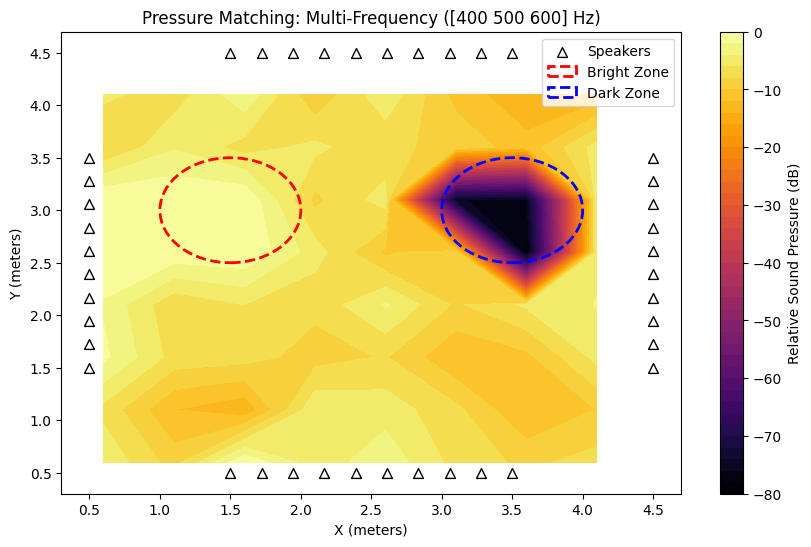

In [28]:
# Initialize an empty energy array for all microphones
energy_tot = np.zeros(num_mics)

# Sum the acoustic energy for ONLY your specified audio frequencies
for i, target_freq in enumerate(audio_freq):
    freq_bin = int(np.round((target_freq / fs) * nfft))
    p_freq = p_full[:, freq_bin]
    amp = audio_amp[i]
    energy_tot += np.abs(amp * p_freq)**2

# 1. Convert total energy back to RMS pressure
p_total_rms = np.sqrt(energy_tot)

# 2. Convert to Decibels (dB) here, and normalize so the loudest point is 0 dB.
# This makes it much easier to read the true "Contrast Ratio" between zones.
p_dB = 20 * np.log10(p_total_rms + 1e-12)
p_dB = p_dB - np.max(p_dB) 

# 3. Reshape for the plot
pressure_map = p_dB.reshape(X.shape)

# Plotting
plt.figure(figsize=(10, 6))
plt.contourf(X, Y, pressure_map, levels=50, cmap='inferno')
plt.colorbar(label="Relative Sound Pressure (dB)")

# Draw Speakers
plt.scatter(all_speakers[0, :], all_speakers[1, :], color='white', edgecolors='black', label='Speakers', marker='^', s=50)

# Draw the Bright Zone circle (Left)
bright_circle = plt.Circle(bright_center, radius, color='red', fill=False, linestyle='--', linewidth=2, label='Bright Zone')
plt.gca().add_patch(bright_circle)

# Draw the Dark Zone circle (Right)
dark_circle = plt.Circle(dark_center, radius, color='blue', fill=False, linestyle='--', linewidth=2, label='Dark Zone')
plt.gca().add_patch(dark_circle)

plt.title(f"Pressure Matching: Multi-Frequency ({audio_freq} Hz)")
plt.xlabel("X (meters)")
plt.ylabel("Y (meters)")
plt.legend()
plt.show()

In [ ]:
# 1. Define the audio properties
duration = 2.0  # seconds
t = np.arange(0, duration, 1/fs)

# 2. Create a fresh room just for listening (saves memory/time)
# We use the same dimensions and properties as your original room
listening_room = pra.ShoeBox(room_dim, fs=fs, max_order=3, air_absorption=True)

# 3. Generate and add the speaker signals using optimal_g
num_speakers = all_speakers.shape[1]
for i in range(num_speakers):
    total_signal = np.zeros(len(t))
    for idx, freq in enumerate(audio_freq):

        # Extract the weights for THIS specific frequency
        freq_bin = int(np.round((freq / fs) * nfft))
        freq_g = g_full[:, freq_bin]
        mag = np.abs(freq_g[i])
        phase = np.angle(freq_g[i])
        amp = audio_amp[idx]
    
        # Create the time-domain sine wave, scaled by your custom amplitude
        freq_signal = amp * mag * np.sin(2 * np.pi * freq * t + phase)
        total_signal += freq_signal
    
    # Add the speaker to the new room at the original coordinates
    listening_room.add_source(all_speakers[:, i], signal=total_signal)


# 4. Add mics to room
bright_mic_pos = [bright_center[0], bright_center[1], 2.5]
dark_mic_pos   = [dark_center[0], dark_center[1], 2.5]
listening_mics_coords = np.array([bright_mic_pos, dark_mic_pos]).T
mic_array = pra.MicrophoneArray(listening_mics_coords, listening_room.fs)
listening_room.add_microphone_array(mic_array)

# 5. Run the Simulation
print("Simulating audio for playback...")
listening_room.simulate()

# 6. Extract the audio signals

# Normalize signals to hear difference rather than pure volume
bright_audio = listening_room.mic_array.signals[0, :]
dark_audio = listening_room.mic_array.signals[1, :]
max_val = max(np.max(np.abs(bright_audio)), np.max(np.abs(dark_audio)))
bright_audio_norm = bright_audio / max_val
dark_audio_norm = dark_audio / max_val

# Convert to 16-bit PCM WAV format
bright_wav = np.int16(bright_audio_norm * 32767)
dark_wav = np.int16(dark_audio_norm * 32767)

# 7. Save the files to your current directory
wav.write("pm_bright_zone_center.wav", fs, bright_wav)
wav.write("pm_dark_zone_center.wav", fs, dark_wav)

print("Audio files saved! Go listen to them.")

Simulating audio for playback...
Audio files saved! Go listen to them.


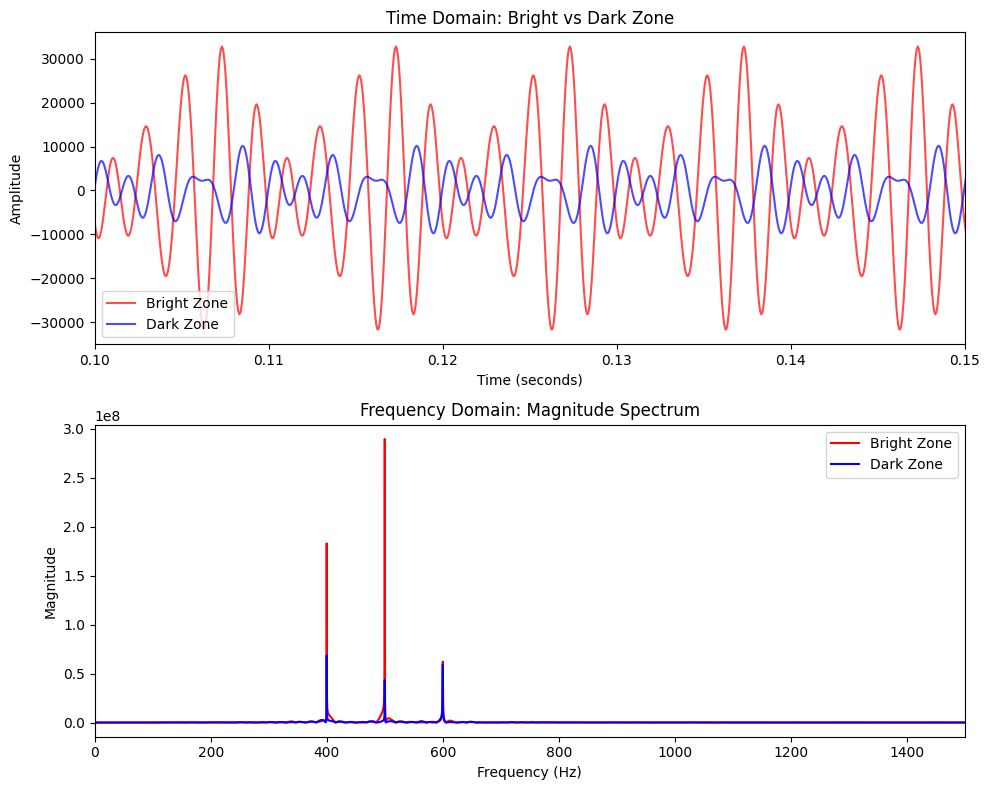

In [31]:
# 1. Load the signals
# wav.read returns (rate, data)
fs_b, b_data = wav.read("bright_zone_center.wav")
fs_d, d_data = wav.read("dark_zone_center.wav")

# Create a time axis for the first plot
t = np.arange(len(b_data)) / fs_b

# 2. Plot Time Domain Signal
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(t, b_data, label='Bright Zone', color='red', alpha=0.7)
ax1.plot(t, d_data, label='Dark Zone', color='blue', alpha=0.7)
ax1.set_title("Time Domain: Bright vs Dark Zone")
ax1.set_xlabel("Time (seconds)")
ax1.set_ylabel("Amplitude")
ax1.legend()
ax1.set_xlim(0.1, 0.15) # Zoom in to see the actual waves

# 3. FFT of signal
# Use rfft for real signals (outputs only positive frequencies)
b_fft = np.fft.rfft(b_data)
d_fft = np.fft.rfft(d_data)

# Create frequency axis
# rfftfreq takes (n_samples, 1/sample_rate)
freq_axis = np.fft.rfftfreq(len(b_data), 1/fs_b)

# Plot Magnitude Spectrum (using np.abs to get magnitude)
ax2.plot(freq_axis, np.abs(b_fft), label='Bright Zone', color='red')
ax2.plot(freq_axis, np.abs(d_fft), label='Dark Zone', color='blue')
ax2.set_title("Frequency Domain: Magnitude Spectrum")
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Magnitude")
ax2.set_xlim(0, 1500) # Zoom into our range of interest (400-600Hz)
ax2.legend()

plt.tight_layout()
plt.show()



